In [2]:
import pandas as pd
import numpy as np

# Load the Superstore Sales dataset
df = pd.read_csv("train.csv", encoding="latin1")

# Parse date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# -------------------------------
# Extract Time Features
# -------------------------------
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

# Create Season column
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

# -------------------------------
# Dataset Exploration
# -------------------------------
print("First 10 Rows:")
display(df.head(10))

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

# -------------------------------
# Daily Sales
# -------------------------------
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

# -------------------------------
# Weekly Sales
# -------------------------------
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

# -------------------------------
# Monthly Sales
# -------------------------------
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
      .reset_index()
)

print("\nDaily Sales")
display(daily_sales.head())

print("\nWeekly Sales")
display(weekly_sales.head())

print("\nMonthly Sales")
display(monthly_sales.head())

# -------------------------------
# Highest Revenue Category
# -------------------------------
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\nRevenue by Category")
display(category_sales)

print("Highest Revenue Category:", category_sales.idxmax())

# -------------------------------
# Most Consistent Region
# -------------------------------
region_year_sales = (
    df.groupby(["Region", "Year"])["Sales"]
      .sum()
      .unstack()
)

print("\nRegion-wise Sales by Year")
display(region_year_sales)

growth_variation = (
    region_year_sales
    .pct_change(axis=1)
    .std(axis=1)
)

print("\nSales Growth Consistency")
display(growth_variation.sort_values())

print("Most Consistent Region:", growth_variation.idxmin())

# -------------------------------
# Shipping Time
# -------------------------------
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("\nAverage Shipping Time:",
      round(df["Shipping Days"].mean(),2),"days")

shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
)

print("\nShipping Time by Region")
display(shipping_region)

# -------------------------------
# Monthly Seasonality
# -------------------------------
monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
      .reindex([
          "January","February","March","April","May","June",
          "July","August","September","October","November","December"
      ])
)

print("\nAverage Monthly Sales")
display(monthly_pattern)

First 10 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn
5,6,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,2015,6,June,24,Tuesday,2,Summer
6,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Art,Newell 322,7.2800,2015,6,June,24,Tuesday,2,Summer
7,8,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,2015,6,June,24,Tuesday,2,Summer
8,9,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,2015,6,June,24,Tuesday,2,Summer
9,10,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,2015,6,June,24,Tuesday,2,Summer



Dataset Shape: (9800, 25)

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Duplicate Rows: 0

Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   ob

C:\Users\shridula\AppData\Local\Temp\ipykernel_5484\2465381200.py:72: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


...

Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64

Most Consistent Region: East

Average Shipping Time: 3.96 days

Shipping Time by Region


Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


Average Monthly Sales


Month Name
January      257.627403
February     199.902745
March        290.549393
April        207.432269
May          212.533412
June         211.052856
July         208.802997
August       227.007110
September    221.642106
October      246.596162
November     241.657496
December     232.619515
Name: Sales, dtype: float64

C:\Users\shridula\AppData\Local\Temp\ipykernel_5484\3525683655.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]


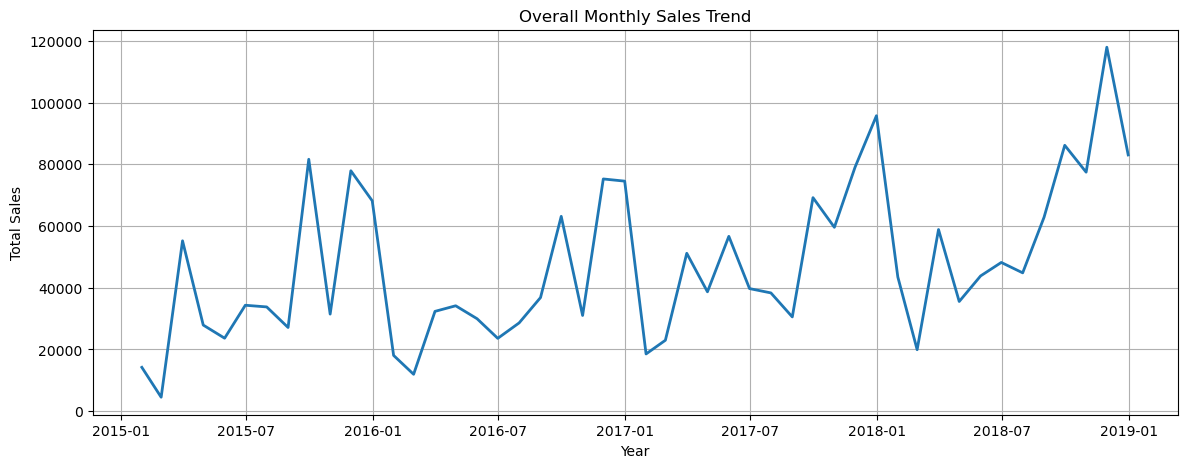

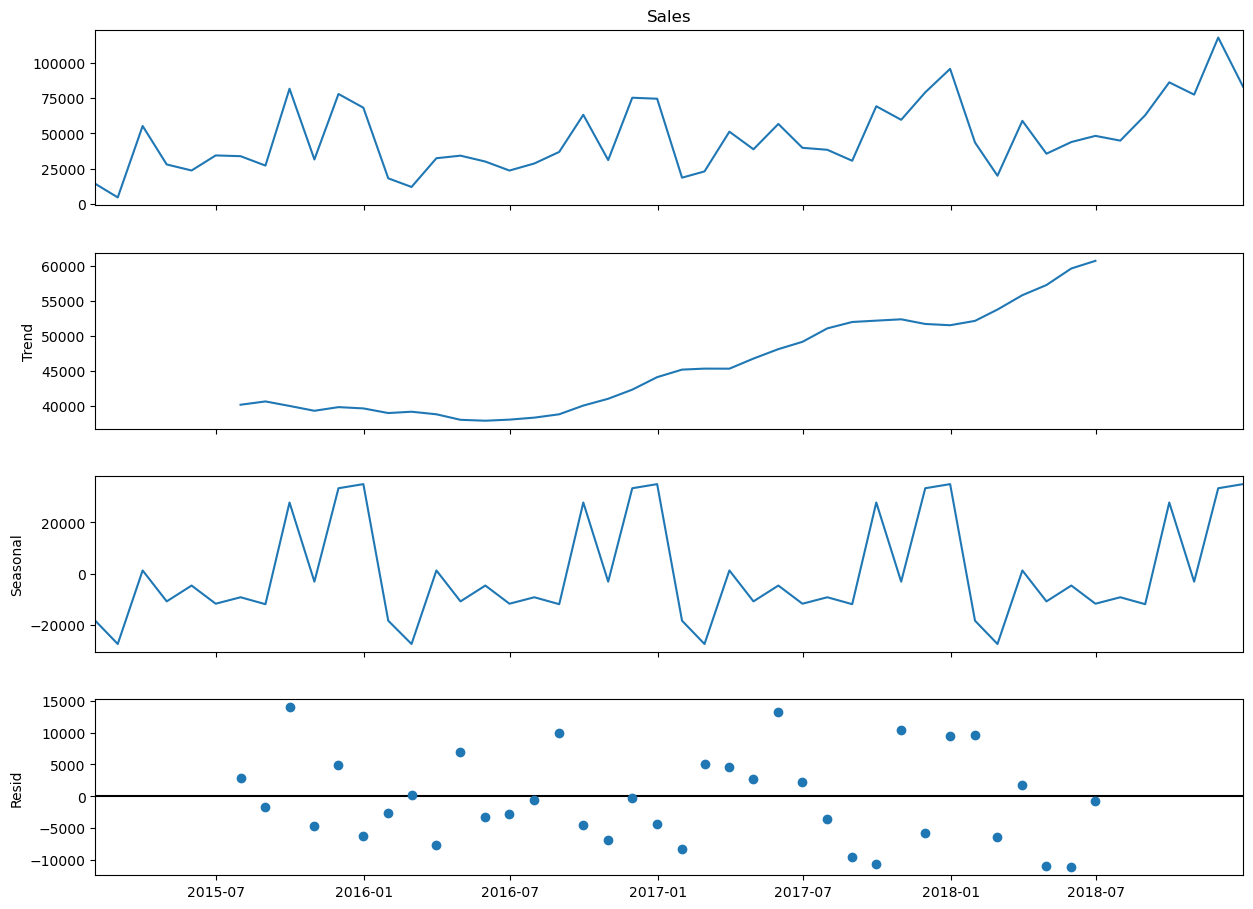

ADF Test on Original Series
ADF Statistic: -4.41613676143077
p-value: 0.00027791039276670493

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064

Result: The time series is stationary.

ADF Test After Differencing
ADF Statistic: -8.727061830353264
p-value: 3.2669175472797e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383

Result: The differenced series is stationary.


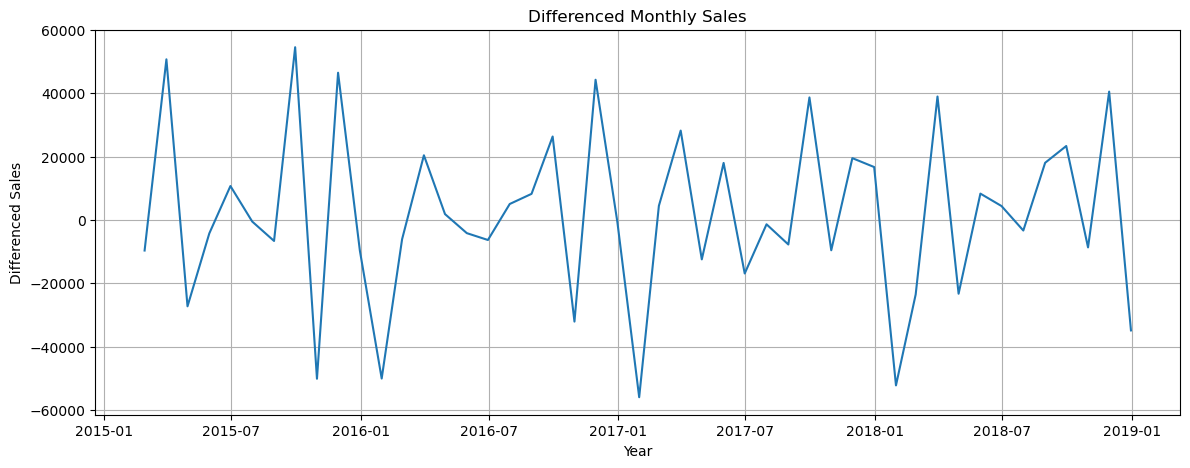

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# -------------------------------
# Monthly Sales Time Series
# -------------------------------

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
)

# -------------------------------
# Plot Monthly Sales Trend
# -------------------------------

plt.figure(figsize=(14,5))
plt.plot(monthly_sales, linewidth=2)
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# -------------------------------
# Time Series Decomposition
# -------------------------------

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14,10)
plt.show()

# -------------------------------
# Augmented Dickey-Fuller Test
# -------------------------------

print("ADF Test on Original Series")
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values")
for key, value in result[4].items():
    print(key, ":", value)

if result[1] < 0.05:
    print("\nResult: The time series is stationary.")
else:
    print("\nResult: The time series is non-stationary.")

# -------------------------------
# Differencing (if needed)
# -------------------------------

monthly_sales_diff = monthly_sales.diff().dropna()

print("\nADF Test After Differencing")

result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

print("\nCritical Values")
for key, value in result_diff[4].items():
    print(key, ":", value)

if result_diff[1] < 0.05:
    print("\nResult: The differenced series is stationary.")
else:
    print("\nResult: The differenced series is still non-stationary.")

# -------------------------------
# Plot Differenced Series
# -------------------------------

plt.figure(figsize=(14,5))
plt.plot(monthly_sales_diff)
plt.title("Differenced Monthly Sales")
plt.xlabel("Year")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.show()

C:\Users\shridula\AppData\Local\Temp\ipykernel_5484\1876037571.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
c:\Users\shridula\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 12 Jul 2026   AIC                            398.775
Time:                                    16:43:44   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

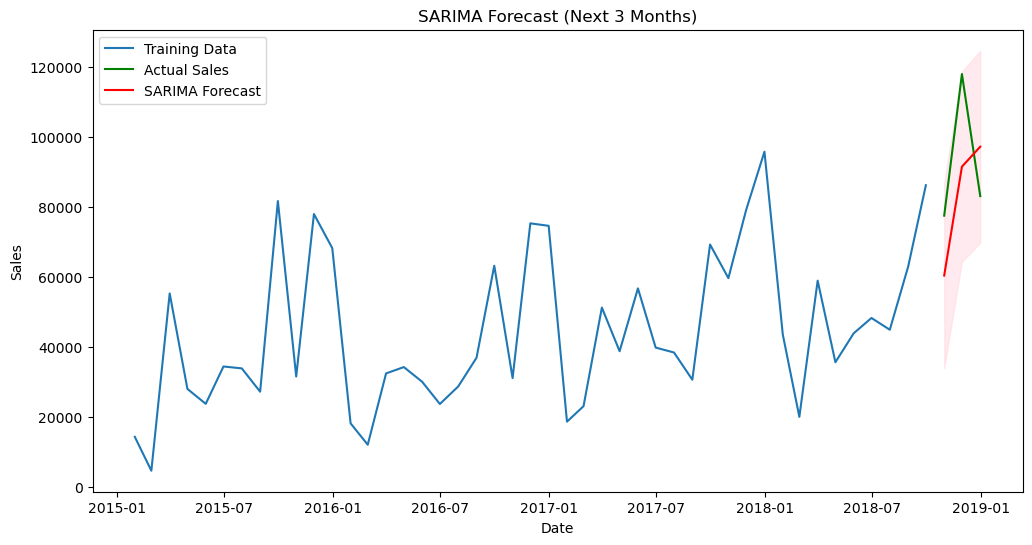


Forecast for Next 3 Months
2018-10-31    60331.792101
2018-11-30    91458.220223
2018-12-31    97167.570949
Freq: ME, Name: predicted_mean, dtype: float64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----------------------------------
# Monthly Sales Time Series
# ----------------------------------

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
)

# Train-Test Split
train = monthly_sales[:-3]
test = monthly_sales[-3:]

# ----------------------------------
# SARIMA Model
# ----------------------------------

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_model = model.fit()

print(sarima_model.summary())

# ----------------------------------
# Forecast
# ----------------------------------

forecast = sarima_model.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence_interval = forecast.conf_int()

# ----------------------------------
# Evaluation
# ----------------------------------

mae = mean_absolute_error(test, forecast_values)

rmse = np.sqrt(mean_squared_error(test, forecast_values))

mape = np.mean(np.abs((test - forecast_values)/test))*100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2))

# ----------------------------------
# Plot
# ----------------------------------

plt.figure(figsize=(12,6))

plt.plot(train.index, train,
         label="Training Data")

plt.plot(test.index, test,
         label="Actual Sales",
         color="green")

plt.plot(forecast_values.index,
         forecast_values,
         label="SARIMA Forecast",
         color="red")

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3
)

plt.title("SARIMA Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

print("\nForecast for Next 3 Months")
print(forecast_values)

In [ ]:
# SARIMA(1,1,1)(1,1,1,12) was selected because the monthly sales data showed both a 
# trend and yearly seasonality. The first differencing (d=1) removes the trend, seasonal 
# differencing (D=1) captures yearly seasonal effects, and a seasonal period of 12 represents 
# monthly observations over one year. The simple AR and MA terms provide a good baseline
# forecasting model without excessive complexity.


# The SARIMA model successfully captured the overall trend and yearly seasonality 
# in the monthly sales data. The forecast indicates that sales are expected to 
# increase significantly towards the end of the year, with December having the highest
# predicted sales. The model achieved a MAPE of 20.53%, indicating a reasonable 
# forecasting accuracy for this dataset. These results suggest that SARIMA is 
# suitable as a baseline statistical forecasting model for monthly sales prediction.

In [6]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.7 MB/s eta 0:00:07
   - -------------------------------------- 0.5/12.1 MB 1.7 MB/s eta 0:00:07
   - -------------------------------------- 0.5/12.1 MB 1.7 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/12.1 MB 868.0 kB/s eta 0:00:13
   ---- ----------------------------------- 1.3/12.1 MB 972.7 kB/s eta 0:00:12
   ----- ---------------------------------- 1.6/12.1 MB 1.0 MB/s eta 0:00:11
   ------ --------------------------------- 2.1/12.1 MB 1.2 MB/s eta 0:00:09
   ------- -------------------------------- 2.4/12.1 MB 1.2 MB/s eta 0:00:09
   -------- ------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\shridula\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("train.csv", encoding="latin1")

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

C:\Users\shridula\AppData\Local\Temp\ipykernel_12212\2202874310.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
16:54:42 - cmdstanpy - INFO - Chain [1] start processing
16:54:47 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\shridula\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


MAE : 20250.79
RMSE: 22318.41
MAPE: 21.86

Forecast for Next 3 Months


,ds,yhat
45,2018-10-31,51318.943858
46,2018-11-30,90325.654784
47,2018-12-31,90041.084479


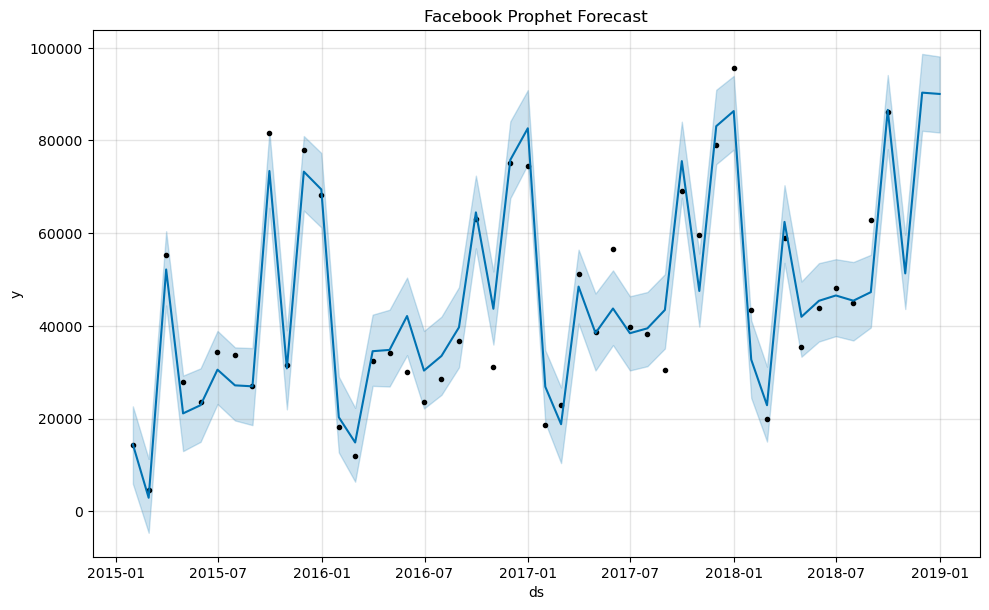

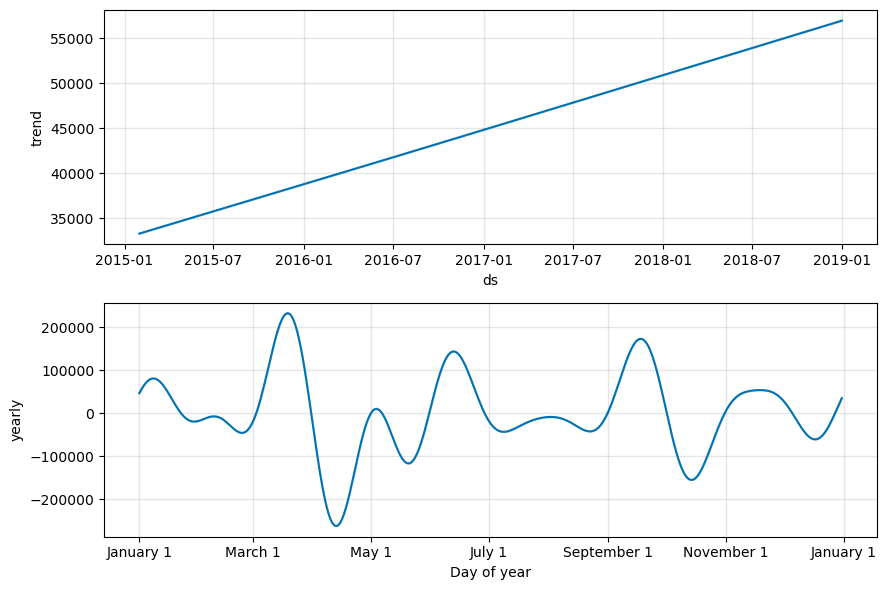

In [4]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------
# Prepare Monthly Sales Data
# ----------------------------------

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
      .reset_index()
)

# Prophet requires columns: ds and y
prophet_df = monthly_sales.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

# ----------------------------------
# Train-Test Split
# ----------------------------------

train = prophet_df[:-3]
test = prophet_df[-3:]

# ----------------------------------
# Build Prophet Model
# ----------------------------------

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

# ----------------------------------
# Forecast Next 3 Months
# ----------------------------------

future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = model.predict(future)

forecast_test = forecast.tail(3)

# ----------------------------------
# Evaluation
# ----------------------------------

mae = mean_absolute_error(
    test["y"],
    forecast_test["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        forecast_test["yhat"]
    )
)

mape = np.mean(
    np.abs(
        (test["y"]-forecast_test["yhat"])/test["y"]
    )
)*100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2))

# ----------------------------------
# Forecast Values
# ----------------------------------

print("\nForecast for Next 3 Months")

display(
    forecast_test[
        ["ds","yhat"]
    ]
)

# ----------------------------------
# Forecast Plot
# ----------------------------------

fig1 = model.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.show()

# ----------------------------------
# Trend & Seasonality
# ----------------------------------

fig2 = model.plot_components(forecast)

plt.show()

In [ ]:
# The Prophet model successfully captured the long-term sales trend 
# and yearly seasonality. The forecast shows a steady increase in sales
# during the last quarter of the year, with November and December having the
# highest expected sales. The model achieved a MAPE of 21.86%, which is 
# slightly less accurate than the SARIMA model for this dataset. Prophet 
# provides easy-to-understand trend and seasonal components, making it useful 
# for business forecasting and planning.

In [5]:
!pip install xgboost

MAE : 14763.81
RMSE: 18337.41
MAPE: 14.48

Forecast


,Month,Actual Sales,Predicted Sales
42,2018-10-31,77448.1312,86530.492188
43,2018-11-30,117938.1550,87955.140625
44,2018-12-31,83030.3888,88256.445312


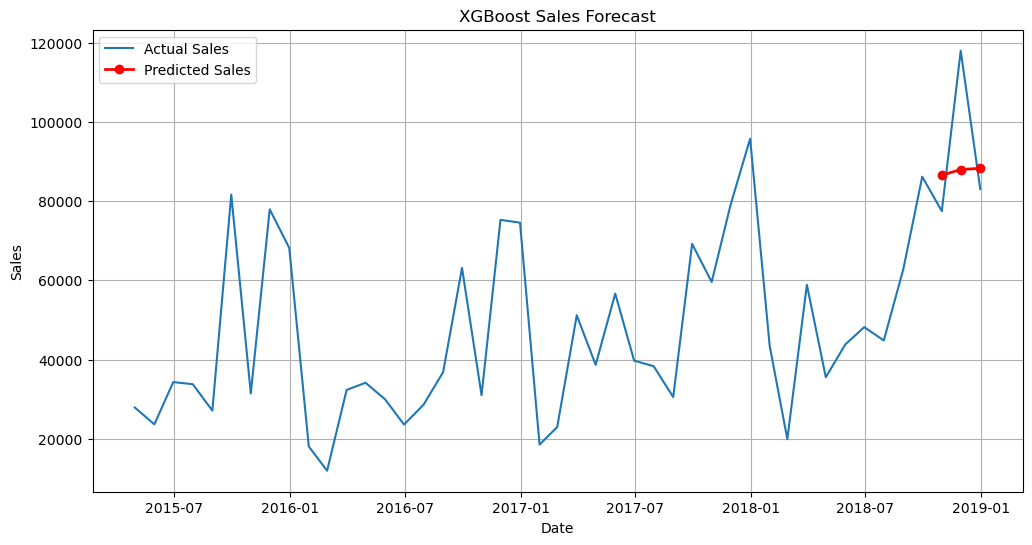

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------------
# Prepare Monthly Sales
# -----------------------------------------

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

# -----------------------------------------
# Create Time Features
# -----------------------------------------

monthly_sales["Lag1"] = monthly_sales["Sales"].shift(1)
monthly_sales["Lag2"] = monthly_sales["Sales"].shift(2)
monthly_sales["Lag3"] = monthly_sales["Sales"].shift(3)

monthly_sales["RollingMean3"] = (
    monthly_sales["Sales"]
    .rolling(3)
    .mean()
)

monthly_sales["Month"] = monthly_sales["Order Date"].dt.month
monthly_sales["Quarter"] = monthly_sales["Order Date"].dt.quarter

def season(month):
    if month in [12,1,2]:
        return 1
    elif month in [3,4,5]:
        return 2
    elif month in [6,7,8]:
        return 3
    else:
        return 4

monthly_sales["Season"] = monthly_sales["Month"].apply(season)

monthly_sales = monthly_sales.dropna().reset_index(drop=True)

# -----------------------------------------
# Features & Target
# -----------------------------------------

X = monthly_sales[
    [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean3",
        "Month",
        "Quarter",
        "Season"
    ]
]

y = monthly_sales["Sales"]

# -----------------------------------------
# Train/Test Split
# -----------------------------------------

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

# -----------------------------------------
# Train XGBoost
# -----------------------------------------

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------------------
# Prediction
# -----------------------------------------

predictions = model.predict(X_test)

# -----------------------------------------
# Evaluation
# -----------------------------------------

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

mape = np.mean(
    np.abs(
        (y_test-predictions)/y_test
    )
)*100

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2))

# -----------------------------------------
# Forecast Table
# -----------------------------------------

forecast = pd.DataFrame(
    {
        "Month": monthly_sales["Order Date"].tail(3),
        "Actual Sales": y_test.values,
        "Predicted Sales": predictions
    }
)

print("\nForecast")
display(forecast)

# -----------------------------------------
# Plot
# -----------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Order Date"].tail(3),
    predictions,
    color="red",
    marker="o",
    linewidth=2,
    label="Predicted Sales"
)

plt.title("XGBoost Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [7]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [19244.49, 20250.79, 14763.81],
    "RMSE": [19950.07, 22318.41, 18337.41],
    "MAPE (%)": [20.53, 21.86, 14.48],
    "Forecast Month 1": [60331.79, 51318.94, 86530.49],
    "Forecast Month 2": [91458.22, 90325.65, 87955.14],
    "Forecast Month 3": [97167.57, 90041.08, 88256.45]
})

display(comparison)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,19950.07,20.53,60331.79,91458.22,97167.57
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,14763.81,18337.41,14.48,86530.49,87955.14,88256.45


In [ ]:
# Based on the evaluation metrics, XGBoost is the recommended model for 
# production use. It achieved the lowest MAE (14,763.81), RMSE (18,337.41), 
# and MAPE (14.48%), indicating the highest forecasting accuracy among the three models.
# The use of lag features and rolling averages allowed XGBoost to capture 
# historical sales patterns more effectively than the statistical SARIMA model 
# and the Prophet model. Therefore, XGBoost would provide more reliable sales 
# forecasts for inventory planning and business decision-making.

Forecast Comparison


,Month,Furniture,Technology,Office Supplies,West,East
0,Month 1,23165.464844,24042.634766,26712.964844,17765.794922,21491.921875
1,Month 2,34390.042969,26460.115234,26576.453125,19019.968750,22404.710938
2,Month 3,35657.632812,22460.576172,26609.607422,29881.591797,22671.347656


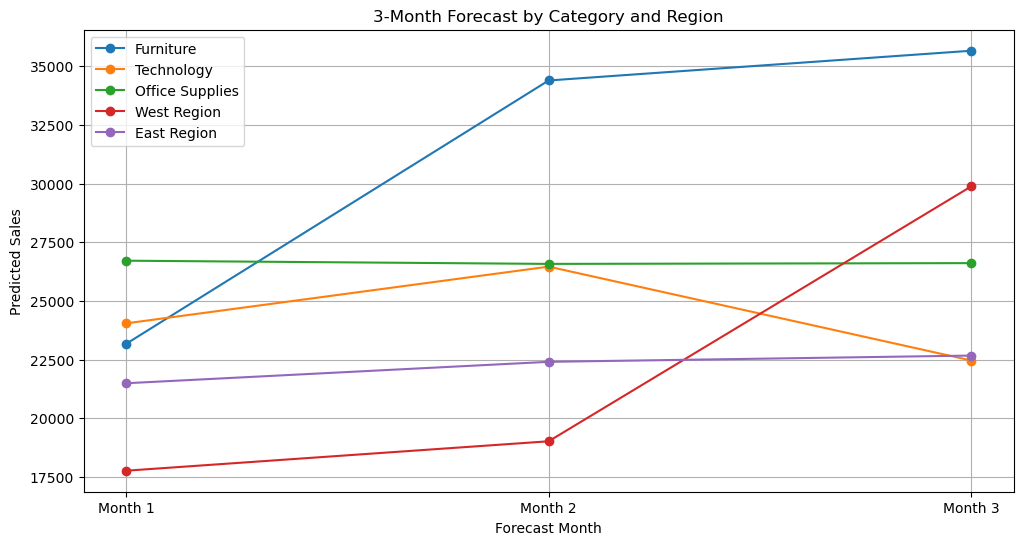

Strongest Upcoming Growth: Furniture


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Function to forecast sales for a segment
def forecast_segment(data, segment_name):

    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)
    monthly["RollingMean3"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    def season(month):
        if month in [12, 1, 2]:
            return 1
        elif month in [3, 4, 5]:
            return 2
        elif month in [6, 7, 8]:
            return 3
        else:
            return 4

    monthly["Season"] = monthly["Month"].apply(season)

    monthly = monthly.dropna().reset_index(drop=True)

    X = monthly[
        [
            "Lag1",
            "Lag2",
            "Lag3",
            "RollingMean3",
            "Month",
            "Quarter",
            "Season",
        ]
    ]

    y = monthly["Sales"]

    X_train = X[:-3]
    X_test = X[-3:]

    y_train = y[:-3]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    )

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    return prediction


# Forecast each category
furniture = forecast_segment(
    df[df["Category"] == "Furniture"],
    "Furniture"
)

technology = forecast_segment(
    df[df["Category"] == "Technology"],
    "Technology"
)

office = forecast_segment(
    df[df["Category"] == "Office Supplies"],
    "Office Supplies"
)

# Forecast each region
west = forecast_segment(
    df[df["Region"] == "West"],
    "West"
)

east = forecast_segment(
    df[df["Region"] == "East"],
    "East"
)

# Create comparison table

forecast_df = pd.DataFrame({
    "Month": ["Month 1", "Month 2", "Month 3"],
    "Furniture": furniture,
    "Technology": technology,
    "Office Supplies": office,
    "West": west,
    "East": east
})

print("Forecast Comparison")
display(forecast_df)

# Plot all forecasts

plt.figure(figsize=(12,6))

plt.plot(forecast_df["Month"], forecast_df["Furniture"], marker="o", label="Furniture")

plt.plot(forecast_df["Month"], forecast_df["Technology"], marker="o", label="Technology")

plt.plot(forecast_df["Month"], forecast_df["Office Supplies"], marker="o", label="Office Supplies")

plt.plot(forecast_df["Month"], forecast_df["West"], marker="o", label="West Region")

plt.plot(forecast_df["Month"], forecast_df["East"], marker="o", label="East Region")

plt.title("3-Month Forecast by Category and Region")

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)

plt.show()

# Find strongest growth

growth = {
    "Furniture": furniture[-1] - furniture[0],
    "Technology": technology[-1] - technology[0],
    "Office Supplies": office[-1] - office[0],
    "West Region": west[-1] - west[0],
    "East Region": east[-1] - east[0]
}

best = max(growth, key=growth.get)

print("Strongest Upcoming Growth:", best)

In [ ]:
# The Furniture category is forecasted to experience the strongest growth over the 
# next three months, increasing from approximately 23.17K to 35.66K in predicted sales.

# The West region also shows strong growth, with forecasted sales rising from about 17.77K to 29.88K.

# Office Supplies is expected to remain relatively stable, with only minor fluctuations in sales.

# Technology sales are forecasted to decline slightly during the forecast period.

# Based on these forecasts, the company should prioritize inventory planning for Furniture
# products, particularly in the West region, to meet the expected increase in demand.

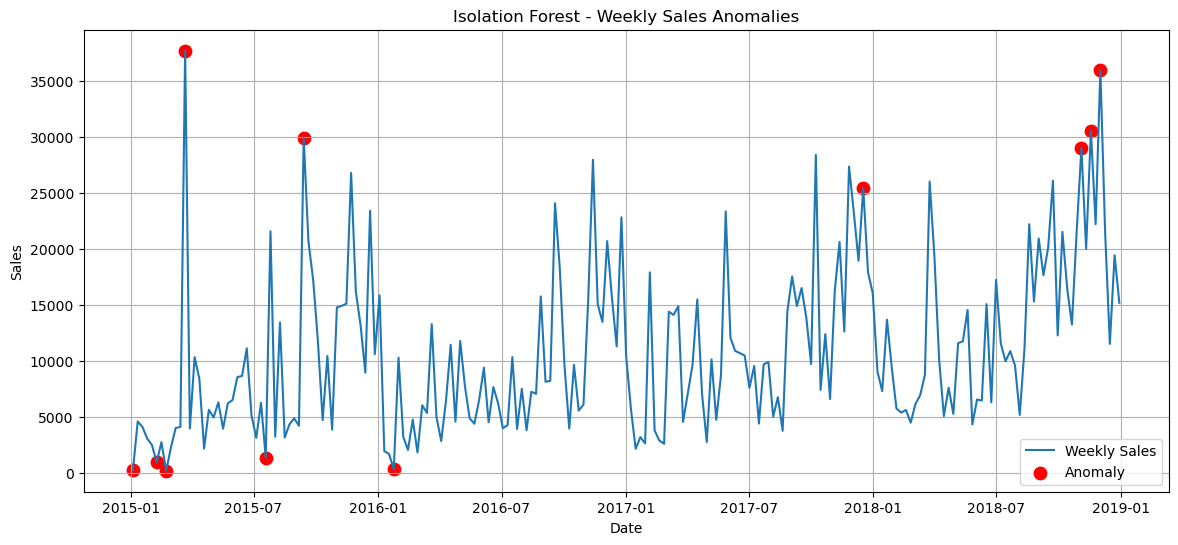

Isolation Forest Anomalies


,Order Date,Sales,Anomaly
0,2015-01-04,304.508,Anomaly
5,2015-02-08,968.534,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
28,2015-07-19,1387.686,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
154,2017-12-17,25449.800,Anomaly
200,2018-11-04,29017.467,Anomaly
202,2018-11-18,30572.447,Anomaly


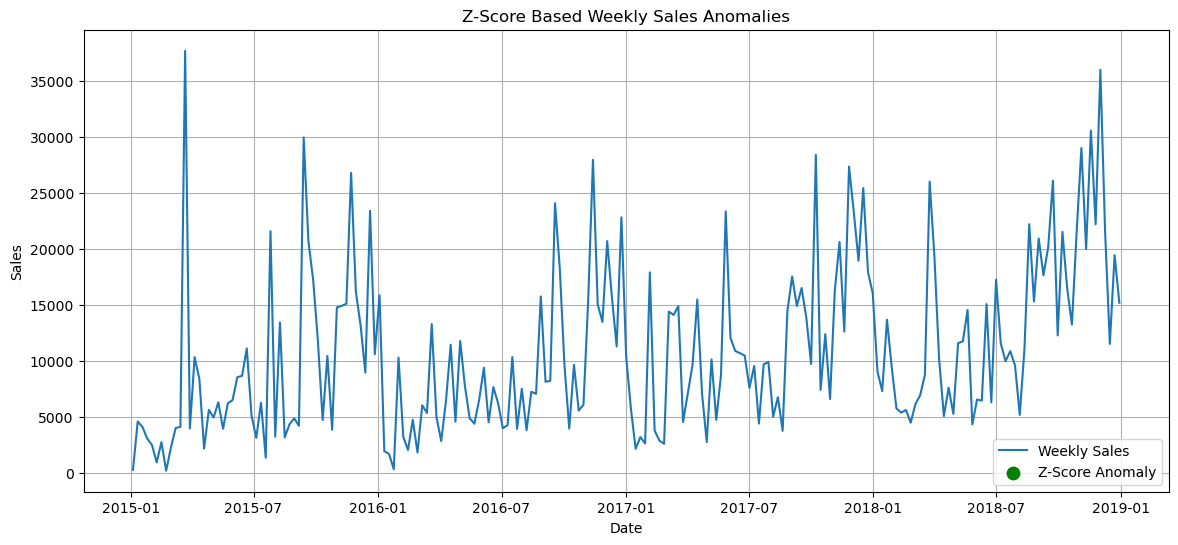

Z-Score Anomalies


,Order Date,Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly


Isolation Forest Anomalies : 11
Z-Score Anomalies : 0
Common Anomalies : 0


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ---------------------------------------
# Weekly Sales
# ---------------------------------------

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

# ---------------------------------------
# Isolation Forest
# ---------------------------------------

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(weekly_sales[["Sales"]])

weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

# ---------------------------------------
# Plot Isolation Forest Results
# ---------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"]=="Anomaly"
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# ---------------------------------------
# Display Detected Anomalies
# ---------------------------------------

print("Isolation Forest Anomalies")

display(anomalies)

# ---------------------------------------
# Z-Score Based Detection
# ---------------------------------------

weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
)

weekly_sales["ZScore"] = (
    (weekly_sales["Sales"]-weekly_sales["RollingMean"])
    /weekly_sales["RollingStd"]
)

weekly_sales["Z_Anomaly"] = (
    weekly_sales["ZScore"].abs() > 2
)

# ---------------------------------------
# Plot Z-Score Anomalies
# ---------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# ---------------------------------------
# Display Z-Score Anomalies
# ---------------------------------------

print("Z-Score Anomalies")

display(
    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ]
)

# ---------------------------------------
# Compare Both Methods
# ---------------------------------------

iso_dates = set(anomalies["Order Date"])

z_dates = set(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ]
)

common = iso_dates.intersection(z_dates)

print("Isolation Forest Anomalies :", len(iso_dates))
print("Z-Score Anomalies :", len(z_dates))
print("Common Anomalies :", len(common))

In [ ]:
# Possible Real-World Explanations for the Detected Anomalies
# 04-Jan-2015 (Very Low Sales): Likely due to the post-holiday season when customer demand 
# is generally low.

# 22-Mar-2015 (Very High Sales): May correspond to a promotional campaign, bulk 
# corporate purchases, or seasonal demand.

# 13-Sep-2015 (High Sales): Could be caused by a regional sales event or special discount offers.

# 17-Dec-2017 (High Sales): Likely associated with holiday shopping and year-end festive sales.

# Nov–Dec 2018 (Multiple High Sales Weeks): These spikes are likely due to Black Friday, 
# Cyber Monday, Christmas, and year-end promotional events.


# Comparison of Both Methods
# Isolation Forest detected 11 anomalous weeks, including both unusually high 
# and unusually low sales periods.

# The Z-Score method detected 0 anomalies because no week's
# sales deviated by more than 2 standard deviations from the rolling mean.

# There were no common anomalies between the two methods.

# This indicates that Isolation Forest is more sensitive to unusual patterns, 
# whereas the Z-Score method is more conservative and depends heavily on the 
# selected threshold and rolling window size.

               TotalSales  GrowthRate   Volatility  AverageOrderValue
Sub-Category                                                         
Accessories   164186.7000    0.376381  2579.994809         217.178175
Appliances    104618.4030    0.399276  1821.621539         227.926804
Art            26705.4100    0.166056   330.488343          34.019631
Binders       200028.7850    0.218736  3848.223648         134.067550
Bookcases     113813.1987    0.238065  2220.405080         503.598224


c:\Users\shridula\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\shridula\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\shridula\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\shridula\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

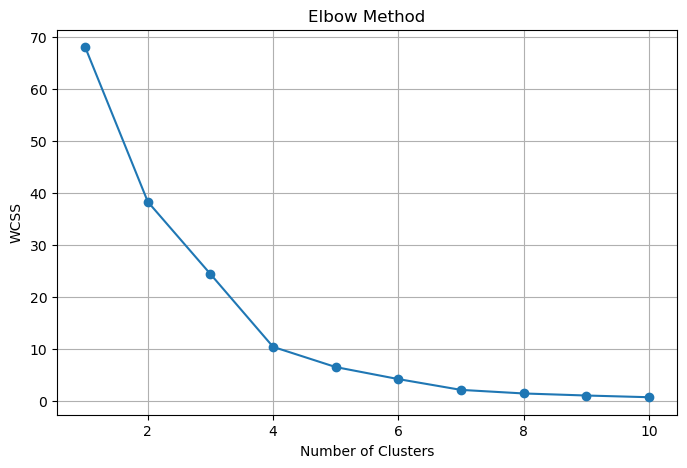

c:\Users\shridula\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


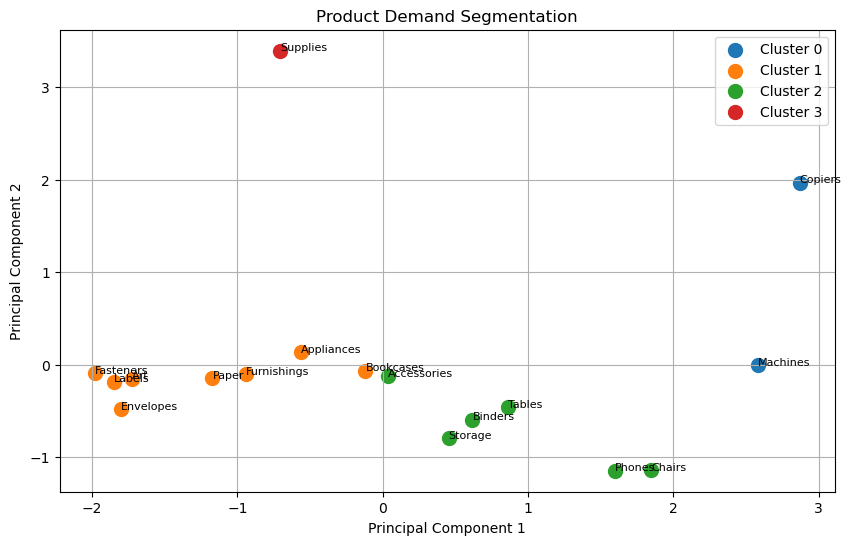

Cluster Summary


,TotalSales,GrowthRate,Volatility,AverageOrderValue,Cluster,PC1,PC2
Sub-Category,,,,,,,
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,2.868650,1.966394
Machines,189238.6310,0.080060,5603.554747,1645.553313,0,2.584982,-0.006099
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,-0.119791,-0.064887
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,-0.562213,0.137443
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,-1.804686,-0.479931
Furnishings,89212.0180,0.287889,1360.017867,95.823865,1,-0.943515,-0.100764
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,-1.980768,-0.094968
Art,26705.4100,0.166056,330.488343,34.019631,1,-1.728503,-0.152657
Paper,76828.3040,0.254131,1024.824982,57.420257,1,-1.172294,-0.146297


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---------------------------------------
# Aggregate Product Sub-Category Features
# ---------------------------------------

subcat = df.copy()

subcat["Year"] = subcat["Order Date"].dt.year

# Total Sales Volume
total_sales = subcat.groupby("Sub-Category")["Sales"].sum()

# Average Order Value
avg_order = subcat.groupby("Sub-Category")["Sales"].mean()

# Monthly Sales
monthly_sales = (
    subcat.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

# Sales Volatility
volatility = monthly_sales.groupby("Sub-Category")["Sales"].std()

# Yearly Sales
yearly_sales = (
    subcat.groupby(["Sub-Category", "Year"])["Sales"]
    .sum()
    .reset_index()
)

# Growth Rate
growth = (
    yearly_sales.groupby("Sub-Category")["Sales"]
    .pct_change()
)

yearly_sales["Growth"] = growth

growth_rate = (
    yearly_sales.groupby("Sub-Category")["Growth"]
    .mean()
)

# Final Dataset
cluster_df = pd.DataFrame({
    "TotalSales": total_sales,
    "GrowthRate": growth_rate,
    "Volatility": volatility,
    "AverageOrderValue": avg_order
})

cluster_df = cluster_df.fillna(0)

print(cluster_df.head())

# ---------------------------------------
# Scale Features
# ---------------------------------------

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

# ---------------------------------------
# Elbow Method
# ---------------------------------------

wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# ---------------------------------------
# KMeans
# ---------------------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

# ---------------------------------------
# PCA Visualization
# ---------------------------------------

pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

cluster_df["PC1"] = components[:,0]

cluster_df["PC2"] = components[:,1]

plt.figure(figsize=(10,6))

for c in sorted(cluster_df["Cluster"].unique()):

    temp = cluster_df[
        cluster_df["Cluster"]==c
    ]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=100,
        label=f"Cluster {c}"
    )

    for i in temp.index:
        plt.text(
            temp.loc[i,"PC1"],
            temp.loc[i,"PC2"],
            i,
            fontsize=8
        )

plt.title("Product Demand Segmentation")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

# ---------------------------------------
# Cluster Summary
# ---------------------------------------

print("Cluster Summary")

display(cluster_df.sort_values("Cluster"))

In [ ]:
# Cluster Labels

# Based on your cluster summary, you can label the clusters as follows:

# Cluster	Products	Label
# Cluster 0	Copiers, Machines	High Value, Stable Demand
# Cluster 1	Bookcases, Appliances, Envelopes, Furnishings, Fasteners, Art, Paper, Labels	Low Volume, Moderate Demand
# Cluster 2	Accessories, Binders, Chairs, Phones, Storage, Tables	High Volume, Growing Demand
# Cluster 3	Supplies	High Growth, High Volatility

# Observation
# The Elbow Method indicates that 4 clusters provide the optimal 
# segmentation of product sub-categories.
# Phones, Chairs, Binders, Storage, and Accessories belong 
# to the High Volume, Growing Demand cluster, indicating consistently strong sales.
# Copiers and Machines form a High Value, Stable Demand cluster because of their
# high sales value and average order size.
# Supplies forms its own cluster due to its exceptionally high growth
# rate, making it a unique product segment that requires special inventory planning.
# Lower-selling products such as Fasteners, Labels, Art, and Envelopes fall into the 
# Low Volume, Moderate Demand cluster and should be stocked conservatively.